# Sonar Image Analysis — Leading Edge

1. Load all PNG images + intensity statistics
2. Apply and compare different filters
3. Each filtered image with its leading edge overlaid
4. Quantitative comparison of leading edges across filters

> **Note:** PNGs are matplotlib preview figures. The loader crops the sonar plot area
> automatically by detecting the dark background region.

In [ ]:
import glob, os
import cv2
import numpy as np
import matplotlib.py
IMAGES_DIR = 'images'
THRESHOLD  = 1   # tune this — used in Sections 3 and 4
IMG_IDX    = 0    # which image to use in Sections 2, 3, 4

print('Images directory:', IMAGES_DIR)
print('Exists:', os.path.isdir(IMAGES_DIR))

Images directory: images
Exists: True


---
## Section 1 — Load images & intensity statistics

Found 20 images



Image                                      Min   Max    Mean     Std  Shape
------------------------------------------------------------------------------
sonar_01_20260311_125540_346.png             0   243     4.2     7.6  (1057, 756)
sonar_01_20260407_174729_209.png             0   241     5.6     9.9  (1057, 743)
sonar_02_20260311_125540_547.png             0   235     2.8     5.7  (1057, 756)
sonar_02_20260407_174729_409.png             0   228     6.0    10.4  (1057, 743)
sonar_03_20260311_125540_747.png             0   234     3.2     6.1  (1057, 756)
sonar_03_20260407_174730_209.png             0   220     4.4     8.0  (1057, 743)
sonar_04_20260311_125540_946.png             0   230     2.8     5.6  (1057, 756)
sonar_04_20260407_174730_609.png             0   222     4.4     8.2  (1057, 743)
sonar_05_20260311_125541_146.png             0   238     3.1     5.9  (1057, 756)
sonar_05_20260407_174731_210.png             0   229     4.5     8.6  (1057, 743)
sonar_06_20260311_125541_

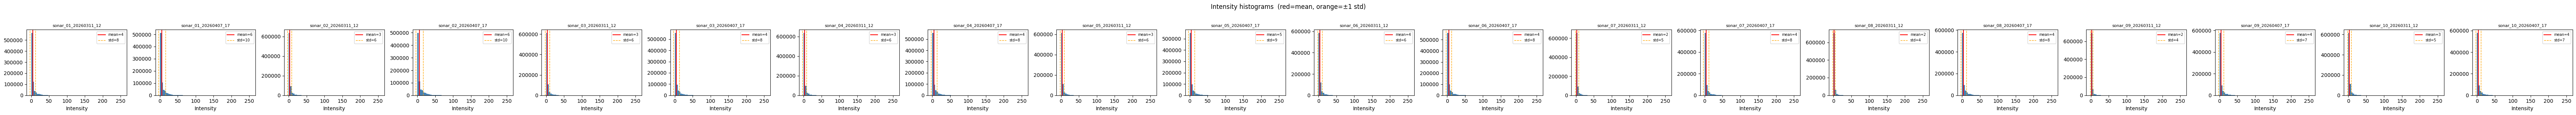

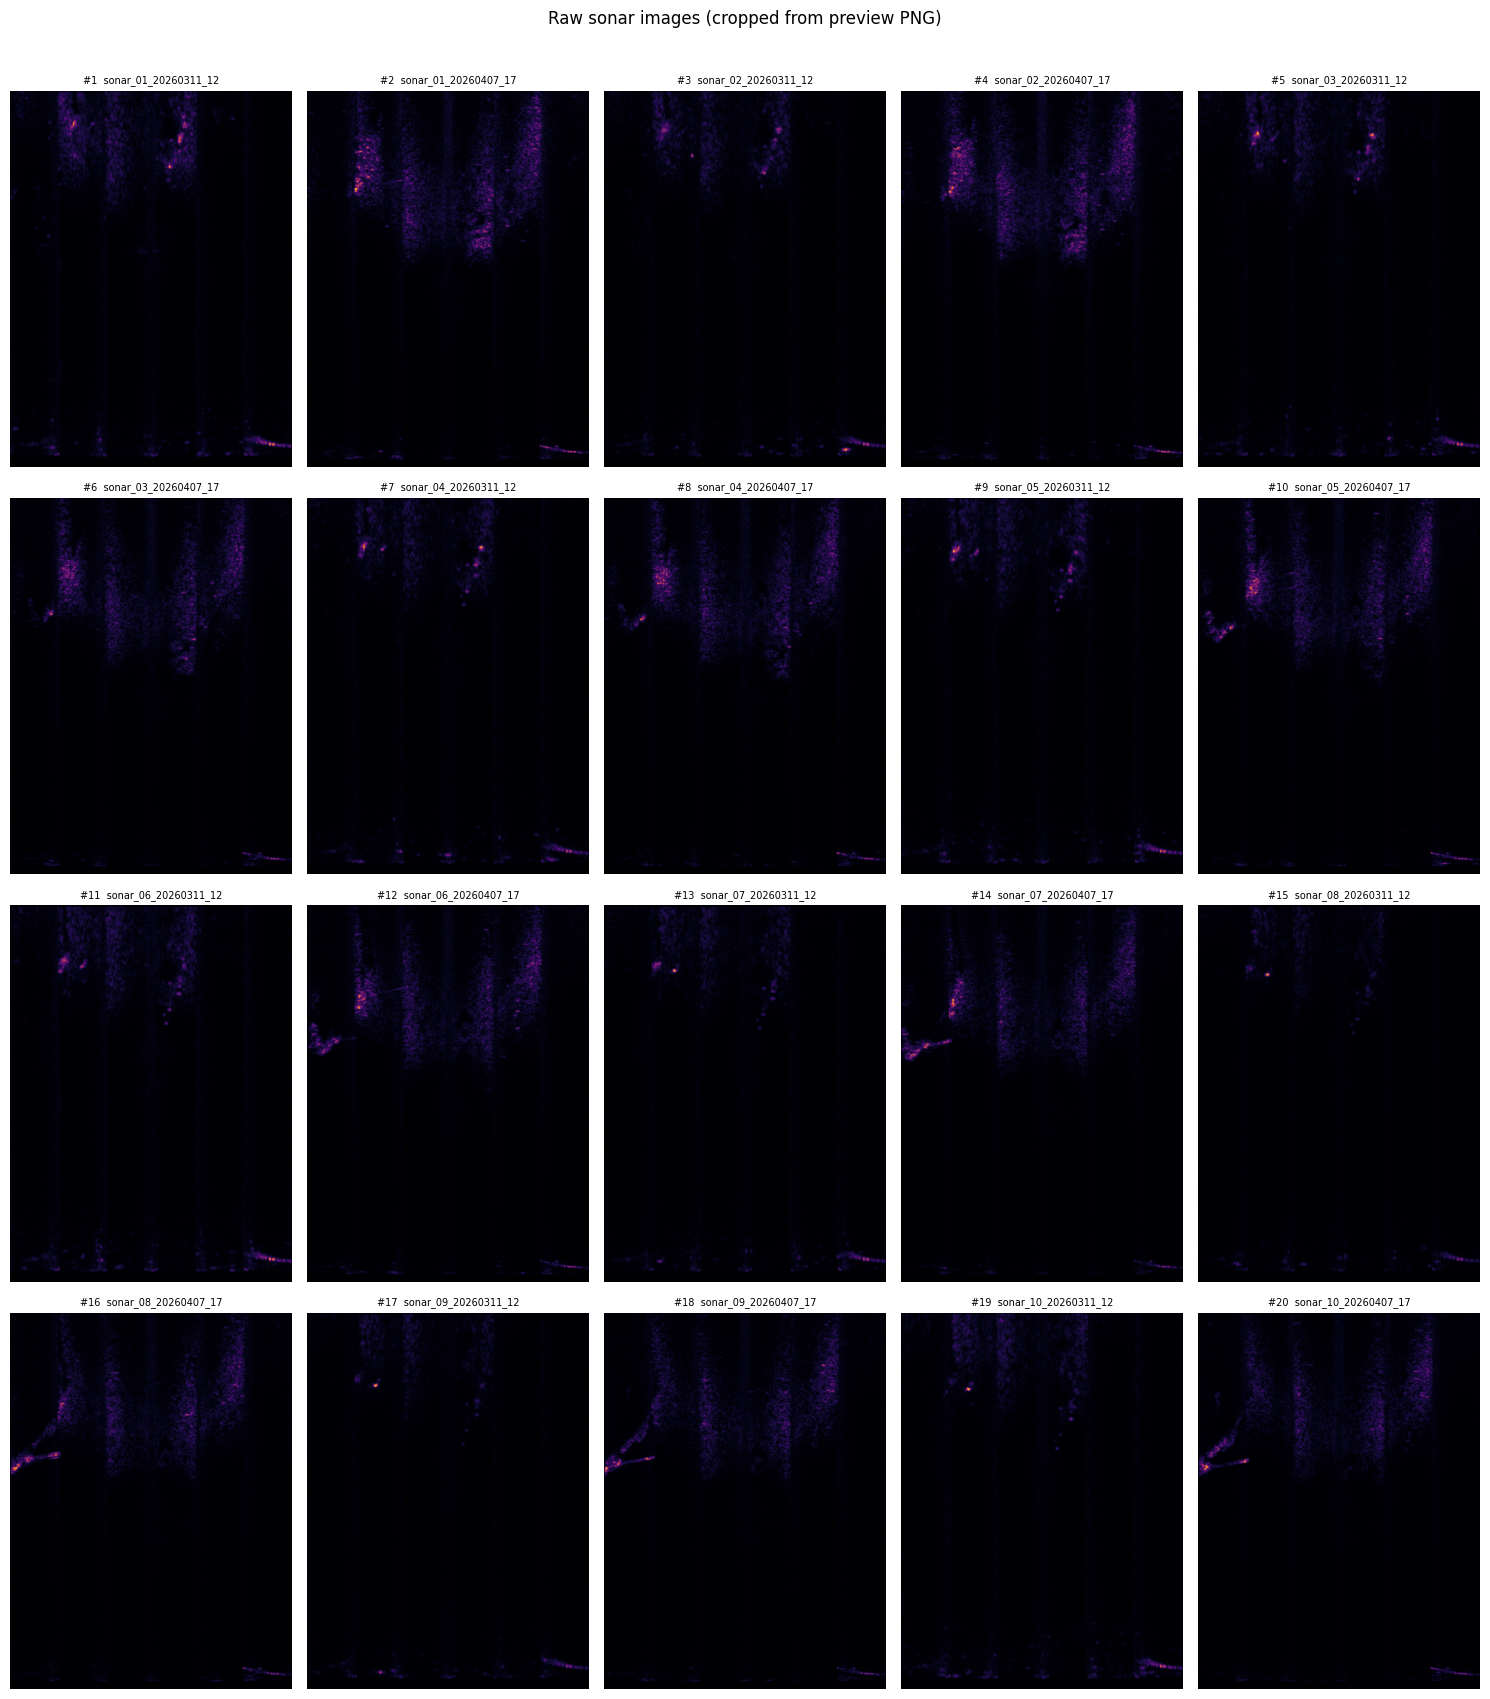

In [ ]:
def crop_sonar_from_figure(path):
    """Crop the sonar plot area from a matplotlib preview PNG.
    Detects the axes region by finding rows/cols whose median R-channel
    value is below 20 (the inferno dark background)."""
    img_color = cv2.imread(path, cv2.IMREAD_COLOR)
    r = img_color[:, :, 2]
    row_med = np.median(r, axis=1)
    col_med = np.median(r, axis=0)
    plot_rows = np.where(row_med < 20)[0]
    plot_cols = np.where(col_med < 20)[0]
    if len(plot_rows) == 0 or len(plot_cols) == 0:
        return cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    crop = img_color[plot_rows[0]:plot_rows[-1]+1,
                     plot_cols[0]:plot_cols[-1]+1]
    return cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)


png_files = sorted(glob.glob(os.path.join(IMAGES_DIR, 'sonar_*.png')))
print(f'Found {len(png_files)} images\n')

scans = []
for path in png_files:
    img = crop_sonar_from_figure(path)
    scans.append({'image': img, 'name': os.path.basename(path)})

# Intensity statistics
print(f'{"Image":<40} {"Min":>5} {"Max":>5} {"Mean":>7} {"Std":>7}  Shape')
print('-' * 78)
for sc in scans:
    img = sc['image']
    print(f'{sc["name"]:<40} {img.min():>5} {img.max():>5} '
          f'{img.mean():>7.1f} {img.std():>7.1f}  {img.shape}')

# Histograms
n = len(scans)
fig, axes = plt.subplots(1, n, figsize=(n * 3.5, 3))
axes = np.array(axes).flatten()
for i, sc in enumerate(scans):
    axes[i].hist(sc['image'].ravel(), bins=64, range=(0, 255),
                 color='steelblue', edgecolor='none')
    m, s = sc['image'].mean(), sc['image'].std()
    axes[i].axvline(m, color='red', lw=1.5, label=f'mean={m:.0f}')
    axes[i].axvline(m + s, color='orange', lw=1, ls='--', label=f'std={s:.0f}')
    axes[i].axvline(m - s, color='orange', lw=1, ls='--')
    axes[i].set_title(sc['name'][:20], fontsize=8)
    axes[i].set_xlabel('Intensity')
    axes[i].legend(fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Intensity histograms  (red=mean, orange=±1 std)', y=1.02)
plt.tight_layout()
plt.show()

# Raw image grid
cols_g = min(n, 5)
rows_g = (n + cols_g - 1) // cols_g
H0, W0 = scans[0]['image'].shape
fig, axes = plt.subplots(rows_g, cols_g,
                         figsize=(cols_g * 3.0, rows_g * 3.0 * H0 / W0))
axes = np.array(axes).flatten()
for i, sc in enumerate(scans):
    axes[i].imshow(sc['image'], cmap='inferno', aspect='auto', vmin=0, vmax=255)
    axes[i].set_title(f'#{i+1}  {sc["name"][:20]}', fontsize=7)
    axes[i].axis('off')
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Raw sonar images (cropped from preview PNG)', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 2 — Filter comparison

Four filters + raw reference on one image.  
Change `IMG_IDX` in the first cell to inspect a different ping.

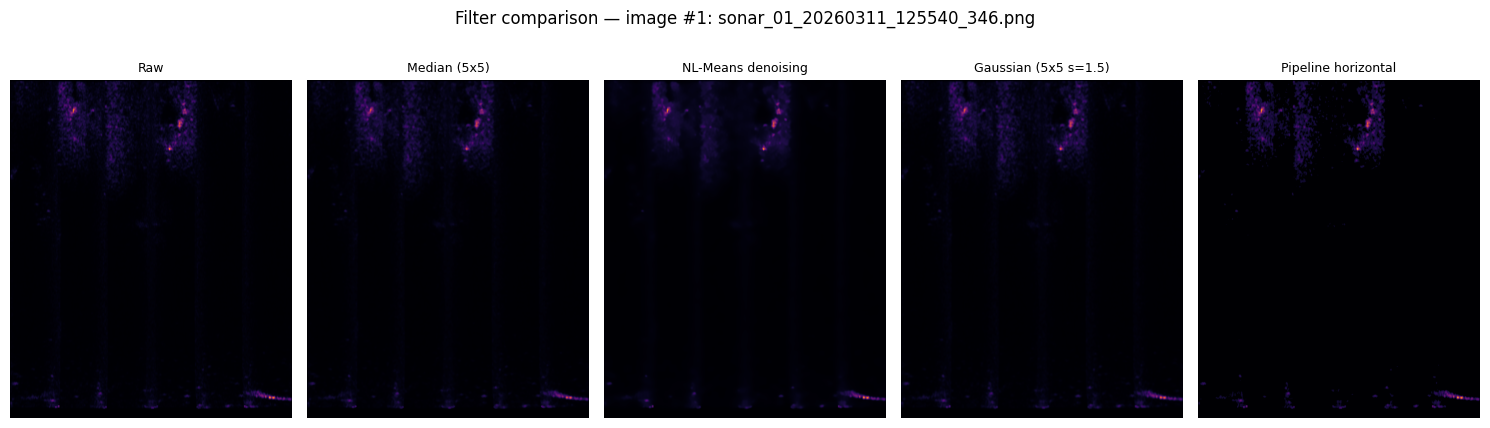

In [ ]:
raw = scans[IMG_IDX]['image'].astype(np.float32)
H, W = raw.shape


def f_raw(img):
    return np.clip(img, 0, 255).astype(np.uint8)


def f_median(img):
    return cv2.medianBlur(np.clip(img, 0, 255).astype(np.uint8), 5)


def f_nlm_denoise(img):
    return cv2.fastNlMeansDenoising(
        np.clip(img, 0, 255).astype(np.uint8),
        h=10, templateWindowSize=7, searchWindowSize=21)


def f_gaussian(img):
    return cv2.GaussianBlur(np.clip(img, 0, 255).astype(np.uint8), (5, 5), 1.5)


def f_horizontal_pipeline(img):
    img = np.maximum(0, img - np.quantile(img, 0.1, axis=1)[:, None])
    img = np.maximum(0, img - np.quantile(img, 0.1))
    if img.max() > 0:
        img = (img / img.max() * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    img *= cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    return img


FILTERS = {
    'Raw':                   f_raw,
    'Median (5x5)':          f_median,
    'NL-Means denoising':    f_nlm_denoise,
    'Gaussian (5x5 s=1.5)':  f_gaussian,
    'Pipeline horizontal':   f_horizontal_pipeline,
}

n_f = len(FILTERS)
fig, axes = plt.subplots(1, n_f, figsize=(n_f * 3.0, 3.0 * H / W))
for ax, (name, fn) in zip(axes, FILTERS.items()):
    ax.imshow(fn(raw.copy()), cmap='inferno', aspect='auto', vmin=0, vmax=255)
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.suptitle(f'Filter comparison — image #{IMG_IDX+1}: {scans[IMG_IDX]["name"]}',
             y=1.01)
plt.tight_layout()
plt.show()

---
## Section 3 — Leading edge overlaid on each filtered image

Leading edge (first row >= `THRESHOLD` per beam column) shown in **lime**.

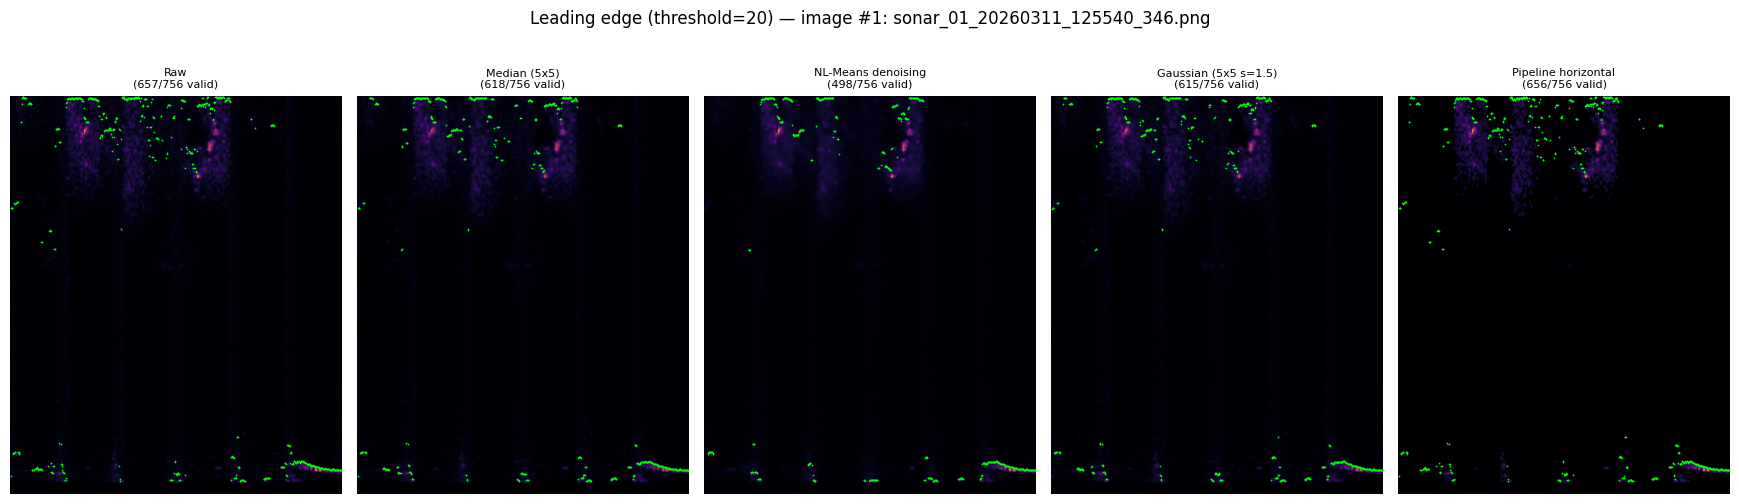

In [ ]:
def leading_edge(img, threshold):
    occupancy = img >= threshold
    edge_row  = np.argmax(occupancy, axis=0)
    valid     = occupancy[edge_row, np.arange(img.shape[1])]
    return edge_row, valid


n_f = len(FILTERS)
fig, axes = plt.subplots(1, n_f, figsize=(n_f * 3.5, 3.5 * H / W))
for ax, (name, fn) in zip(axes, FILTERS.items()):
    filt            = fn(raw.copy())
    edge_row, valid = leading_edge(filt, THRESHOLD)
    valid_cols      = np.where(valid)[0]
    ax.imshow(filt, cmap='inferno', aspect='auto', vmin=0, vmax=255)
    ax.scatter(valid_cols, edge_row[valid_cols], c='lime', s=1.5, linewidths=0)
    ax.set_title(f'{name}\n({valid.sum()}/{filt.shape[1]} valid)', fontsize=8)
    ax.axis('off')
plt.suptitle(
    f'Leading edge (threshold={THRESHOLD}) — '
    f'image #{IMG_IDX+1}: {scans[IMG_IDX]["name"]}', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4 — Leading edge comparison across filters

1. **Overlay** — all edges as curves on one plot
2. **Difference vs Raw** — row shift introduced by each filter per beam column
3. **Smoothness table** — std, mean bias, and max shift vs Raw

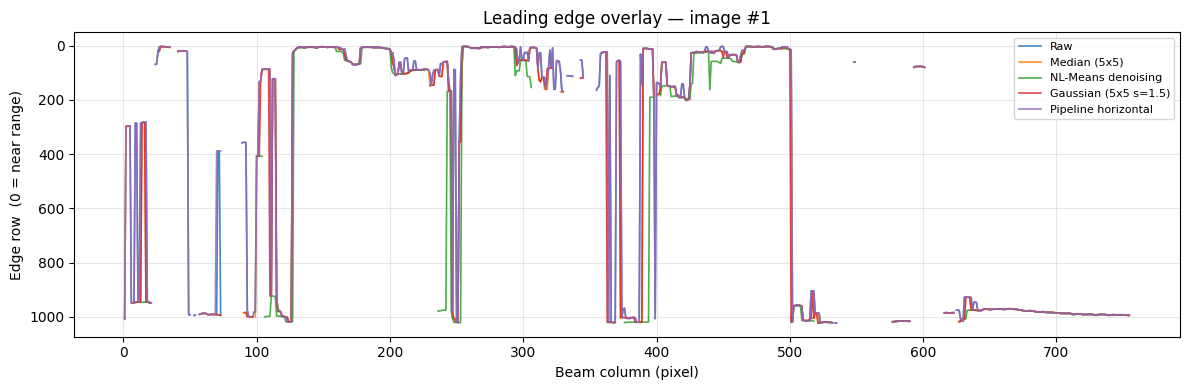

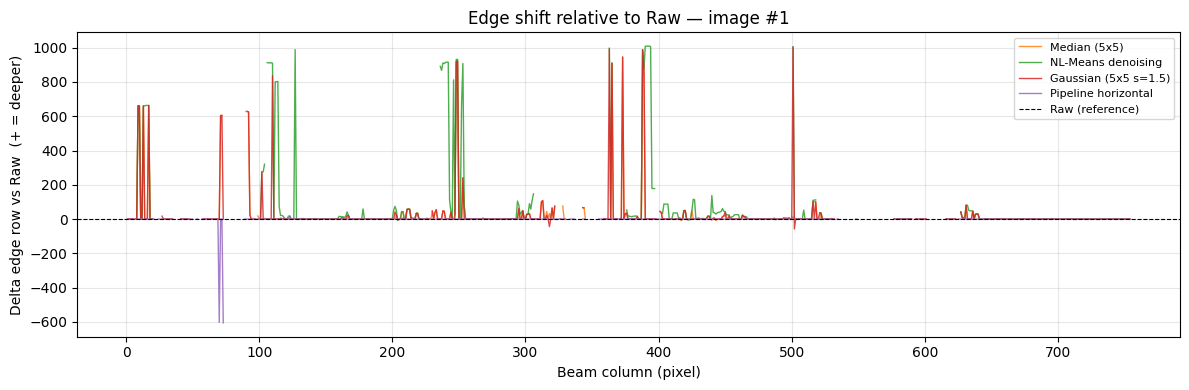


Filter                        Valid%    Edge std    Mean diff vs Raw    Max|diff| vs Raw
----------------------------------------------------------------------------------------
Raw                            86.9%      456.47                0.00                 0.0
Median (5x5)                   81.7%      463.07               23.26               988.0
NL-Means denoising             65.9%      470.09               79.17              1009.0
Gaussian (5x5 s=1.5)           81.3%      463.82               26.76              1004.0
Pipeline horizontal            86.8%      455.26               -1.76               606.0


In [ ]:
# Compute edges for all filters (NaN for invalid columns)
beam_cols = np.arange(W)
edges = {}
for name, fn in FILTERS.items():
    filt = fn(raw.copy())
    edge_row, valid = leading_edge(filt, THRESHOLD)
    edge_f = edge_row.astype(float)
    edge_f[~valid] = np.nan
    edges[name] = edge_f

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 1. Overlay
fig, ax = plt.subplots(figsize=(12, 4))
for i, (name, edge_f) in enumerate(edges.items()):
    ax.plot(beam_cols, edge_f, lw=1.2, alpha=0.85,
            color=colors[i % len(colors)], label=name)
ax.invert_yaxis()
ax.set_xlabel('Beam column (pixel)')
ax.set_ylabel('Edge row  (0 = near range)')
ax.set_title(f'Leading edge overlay — image #{IMG_IDX+1}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Difference vs Raw
raw_edge = edges['Raw']
fig, ax = plt.subplots(figsize=(12, 4))
for i, (name, edge_f) in enumerate(edges.items()):
    if name == 'Raw':
        continue
    diff = edge_f - raw_edge
    ax.plot(beam_cols, diff, lw=1.0, alpha=0.85,
            color=colors[i % len(colors)], label=name)
ax.axhline(0, color='black', lw=0.8, ls='--', label='Raw (reference)')
ax.set_xlabel('Beam column (pixel)')
ax.set_ylabel('Delta edge row vs Raw  (+ = deeper)')
ax.set_title(f'Edge shift relative to Raw — image #{IMG_IDX+1}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Smoothness table
print(f'\n{"Filter":<28} {"Valid%":>7}  {"Edge std":>10}  '
      f'{"Mean diff vs Raw":>18}  {"Max|diff| vs Raw":>18}')
print('-' * 88)
for name, edge_f in edges.items():
    valid_pct  = np.mean(~np.isnan(edge_f)) * 100
    std_val    = np.nanstd(edge_f)
    diff       = edge_f - raw_edge
    mean_diff  = np.nanmean(diff)
    max_diff   = np.nanmax(np.abs(diff))
    print(f'{name:<28} {valid_pct:>6.1f}%  {std_val:>10.2f}  '
          f'{mean_diff:>18.2f}  {max_diff:>18.1f}')